In [2]:
# ============================================================
# LOAD Loan_Default.csv
# ============================================================

from google.colab import drive
import os, glob
import pandas as pd

# 1) Mount Drive
drive.mount("/content/drive")

# 2) Try to find the file anywhere in MyDrive
FILENAME = "Loan_Default.csv"
SEARCH_ROOT = "/content/drive/MyDrive"

matches = glob.glob(os.path.join(SEARCH_ROOT, "**", FILENAME), recursive=True)

if len(matches) == 0:
    raise FileNotFoundError(
        f"Couldn't find {FILENAME} under {SEARCH_ROOT}.\n"
        f"Put the file in MyDrive (or a subfolder), then rerun.\n"
        f"Tip: check spelling/case exactly: {FILENAME}"
    )

# If multiple, pick the most recently modified
matches_sorted = sorted(matches, key=lambda p: os.path.getmtime(p), reverse=True)
path = matches_sorted[0]

print(f"Using file: {path}")

# 3) Load CSV
df = pd.read_csv(path)

# 4) Quick sanity checks
print("\nShape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nHead:")
display(df.head(10))

# 5) Target check (if present)
if "Status" in df.columns:
    print("\nStatus value counts:")
    display(df["Status"].value_counts(dropna=False))
else:
    print("\nColumn 'Status' not found. Available columns above.")

# 6) Missingness (top 25)
print("\nTop missing columns:")
display(df.isna().sum().sort_values(ascending=False).head(25))

Mounted at /content/drive
Using file: /content/drive/MyDrive/Loan_Default.csv

Shape: (148670, 34)

Columns: ['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type', 'loan_purpose', 'Credit_Worthiness', 'open_credit', 'business_or_commercial', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization', 'interest_only', 'lump_sum_payment', 'property_value', 'construction_type', 'occupancy_type', 'Secured_by', 'total_units', 'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type', 'Status', 'dtir1']

Head:


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0



Status value counts:


,count
Status,
0,112031
1,36639



Top missing columns:


,0
Upfront_charges,39642
Interest_rate_spread,36639
rate_of_interest,36439
dtir1,24121
property_value,15098
LTV,15098
income,9150
loan_limit,3344
approv_in_adv,908
age,200


##Exploratory Data Analysis

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

Dataset overview (shape, types, quick glance)

In [4]:
print("Shape:", df.shape)
display(df.head(10))

overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_n": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=True)
}).sort_values(["missing_%", "n_unique"], ascending=[False, False])

display(overview.head(25))

Shape: (148670, 34)


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,...,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,...,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,...,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,...,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,...,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0
5,24895,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,...,EXP,864,EXP,35-44,not_inst,70.089286,North,direct,0,40.0
6,24896,2019,cf,Joint,pre,type1,p3,l1,nopc,nob/c,...,EXP,860,EXP,55-64,to_inst,79.109589,North,direct,0,44.0
7,24897,2019,NaN,Female,nopre,type1,p4,l1,nopc,nob/c,...,CIB,863,CIB,55-64,to_inst,86.525974,North,direct,0,42.0
8,24898,2019,cf,Joint,nopre,type1,p3,l1,nopc,nob/c,...,CIB,580,EXP,55-64,to_inst,78.765690,central,direct,0,44.0
9,24899,2019,cf,Sex Not Available,nopre,type3,p3,l1,nopc,nob/c,...,CIB,788,EXP,55-64,to_inst,63.444767,south,direct,0,30.0


,dtype,missing_n,missing_%,n_unique
Upfront_charges,float64,39642,26.66,58271
Interest_rate_spread,float64,36639,24.64,22516
rate_of_interest,float64,36439,24.51,131
dtir1,float64,24121,16.22,57
LTV,float64,15098,10.16,8484
property_value,float64,15098,10.16,385
income,float64,9150,6.15,1001
loan_limit,object,3344,2.25,2
approv_in_adv,object,908,0.61,2
age,object,200,0.13,7


Target distribution + default rate

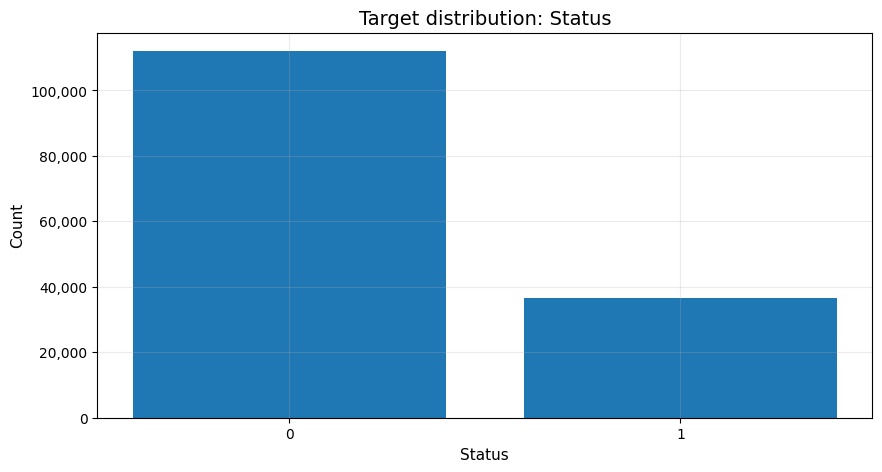

Default rate (mean of Status): 0.2464


In [5]:
if "Status" not in df.columns:
    raise KeyError("Column 'Status' not found. Confirm target column name.")

target_counts = df["Status"].value_counts(dropna=False).sort_index()
default_rate = df["Status"].mean()

fig, ax = plt.subplots()
bars = ax.bar(target_counts.index.astype(str), target_counts.values)
ax.set_title("Target distribution: Status")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
plt.show()

print(f"Default rate (mean of Status): {default_rate:.4f}")

Missingness (top 30) + missingness bar chart

,missing_%
Upfront_charges,26.664425
Interest_rate_spread,24.644515
rate_of_interest,24.509989
dtir1,16.224524
property_value,10.155378
LTV,10.155378
income,6.154571
loan_limit,2.249277
approv_in_adv,0.610749
age,0.134526


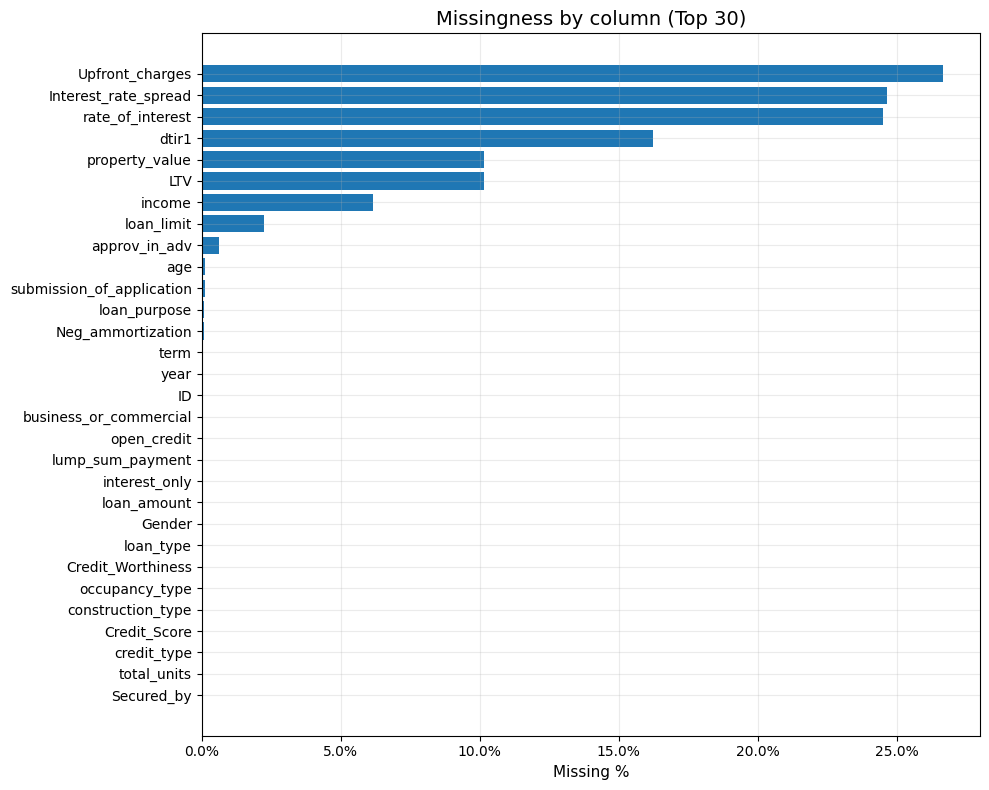

In [6]:
miss = (df.isna().mean() * 100).sort_values(ascending=False)
display(miss.head(30).to_frame("missing_%"))

top = miss.head(30)[::-1]  # reverse for nicer plot (largest at top)
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(top.index, top.values)
ax.set_title("Missingness by column (Top 30)")
ax.set_xlabel("Missing %")
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

The dataset exhibits moderate missingness concentrated in a small subset of financial variables. The highest levels of missing data occur in Upfront_charges (27%)  Interest_rate_spread (25%), and rate_of_interest (24%), followed by dtir1 (16%), property_value (10%), and LTV (10%). Most remaining variables contain minimal or negligible missing values. Because missingness is primarily limited to numeric predictors rather than the target variable, these fields are handled through preprocessing within the modeling pipeline. Numeric variables are imputed using median imputation, while categorical variables are assigned a placeholder category prior to one-hot encoding, allowing the full dataset to be retained for model estimation.

Numeric distributions (histograms + winsorized view)

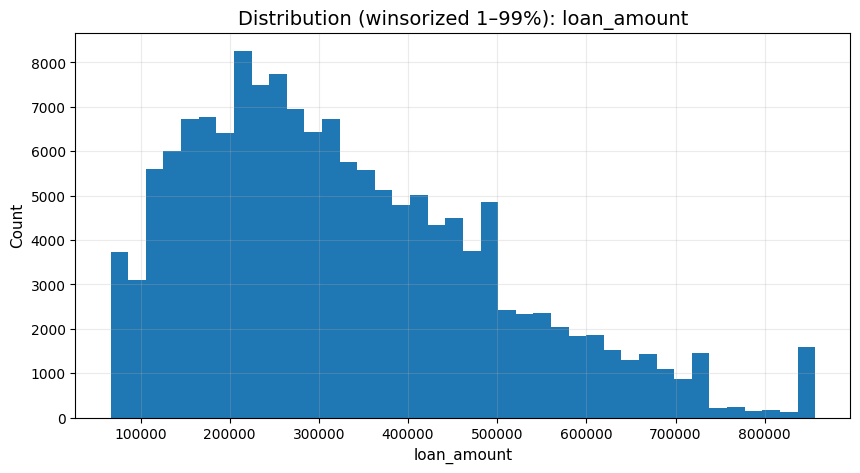

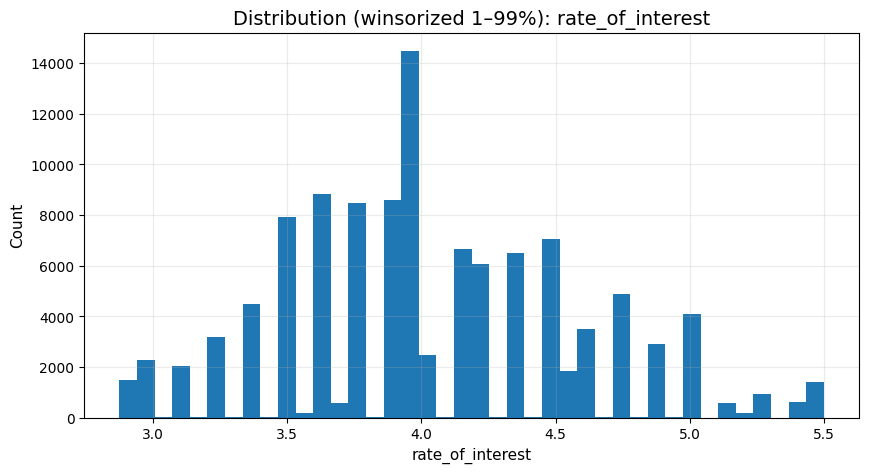

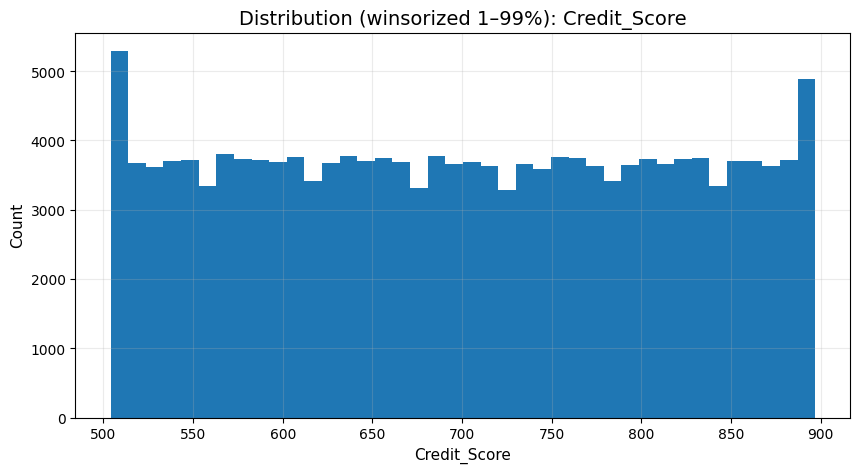

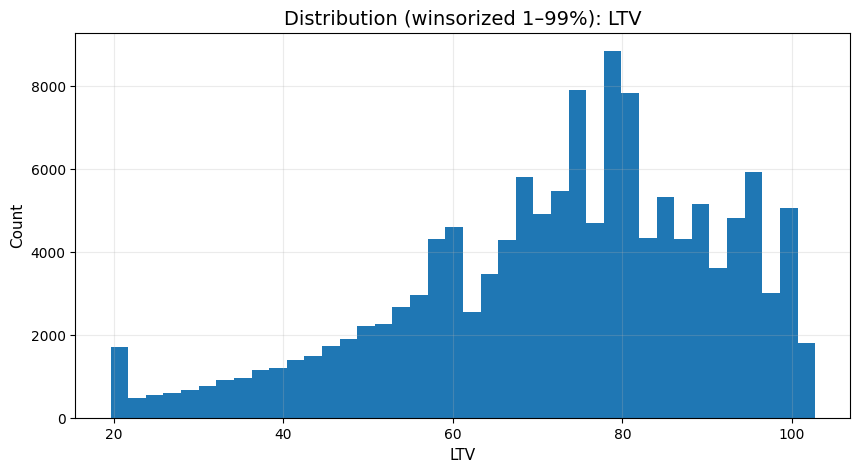

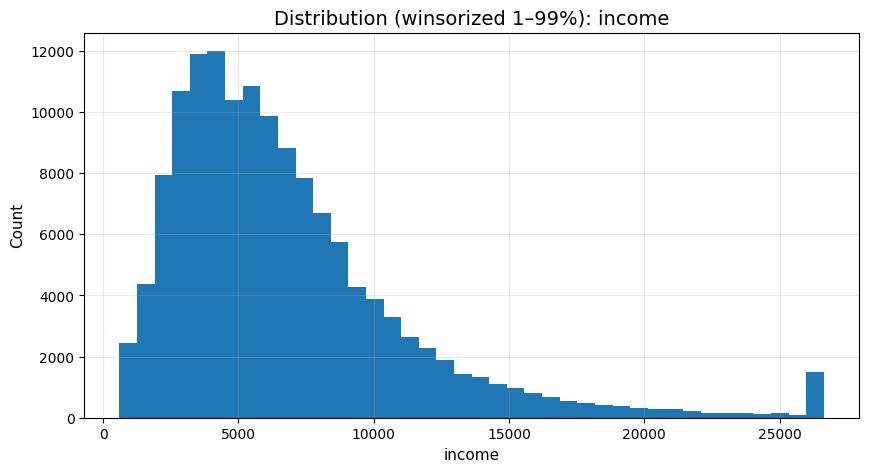

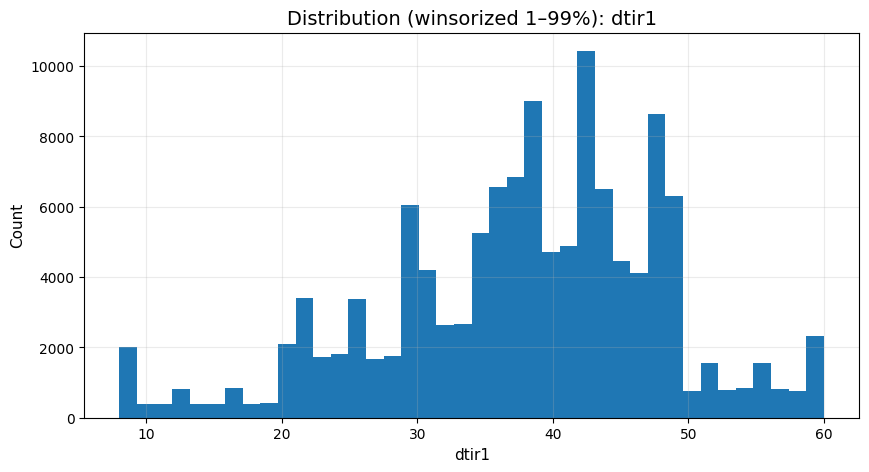

In [7]:
numeric_candidates = ["loan_amount", "rate_of_interest", "Credit_Score", "LTV", "income", "dtir1"]
num_cols = [c for c in numeric_candidates if c in df.columns]

# Coerce to numeric (won't overwrite df yet; just for EDA)
num_eda = df[num_cols].apply(pd.to_numeric, errors="coerce")

for c in num_cols:
    x = num_eda[c].dropna()
    if x.empty:
        print(f"{c}: all missing after coercion")
        continue

    # winsorized view for plot (reduce extreme tail dominance)
    lo, hi = np.nanpercentile(x, [1, 99])
    xw = x.clip(lo, hi)

    fig, ax = plt.subplots()
    ax.hist(xw, bins=40)
    ax.set_title(f"Distribution (winsorized 1–99%): {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Count")
    plt.show()

The distributions of key numeric predictors provide an overview of borrower and loan characteristics in the dataset. Interest rates are concentrated primarily between approximately 3.5% and 4.5%, with a peak around 4%, indicating relatively similar pricing across most loans with fewer high-rate observations. Loan amounts exhibit a right-skewed distribution, with the majority of loans falling between roughly $150,000 and $400,000, while a smaller number of high-value loans extend well above this range. Credit scores span a broad range from approximately 520 to 900, suggesting the dataset includes borrowers with varying levels of creditworthiness. The loan-to-value (LTV) ratio is concentrated mostly between 60% and 90%, with the highest density around 75–80%, reflecting typical mortgage leverage levels. Finally, borrower income displays a strong right-skewed distribution, with most observations between $3,000 and $10,000 and a long upper tail representing higher-income borrowers. Overall, these distributions indicate substantial variability in borrower financial characteristics and loan structures across the dataset. Given the heterogeneity and potential nonlinear relationships between financial variables and default risk, a Bayesian logistic regression is used as a baseline probabilistic classifier, while a Bayesian Generalized Additive Model (GAM) is employed to flexibly capture nonlinear effects of key predictors such as credit score, income, and LTV while retaining interpretable probabilistic inference.

Numeric vs default (binned default rate curves)

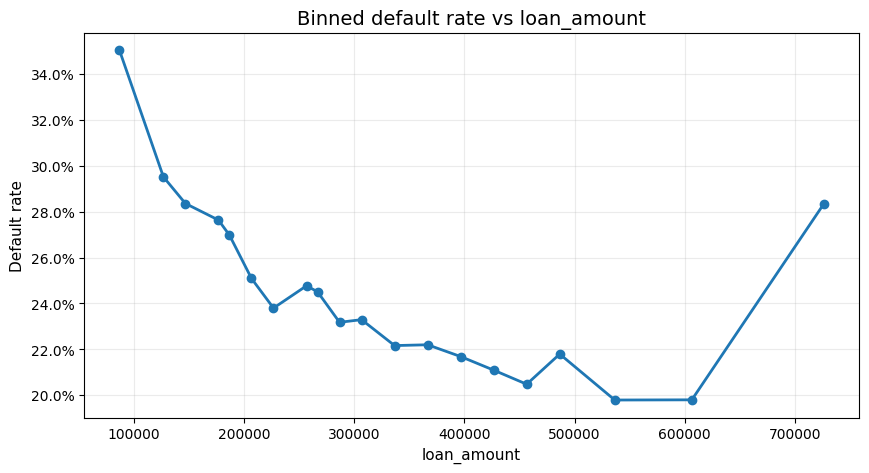

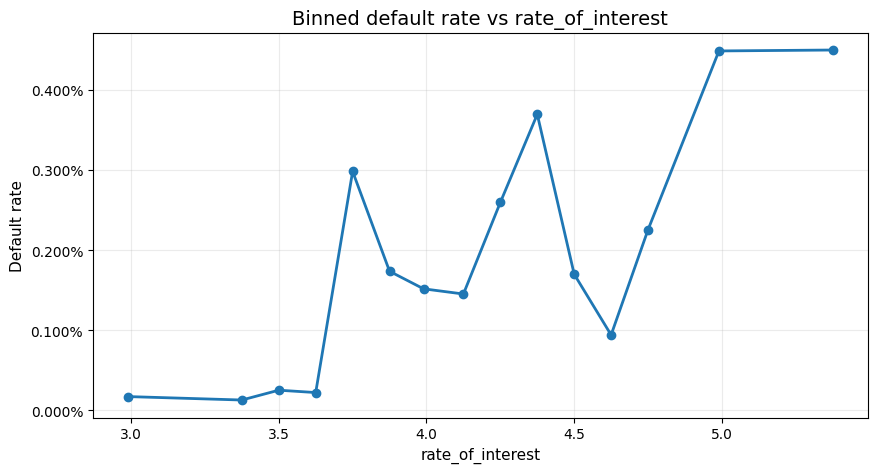

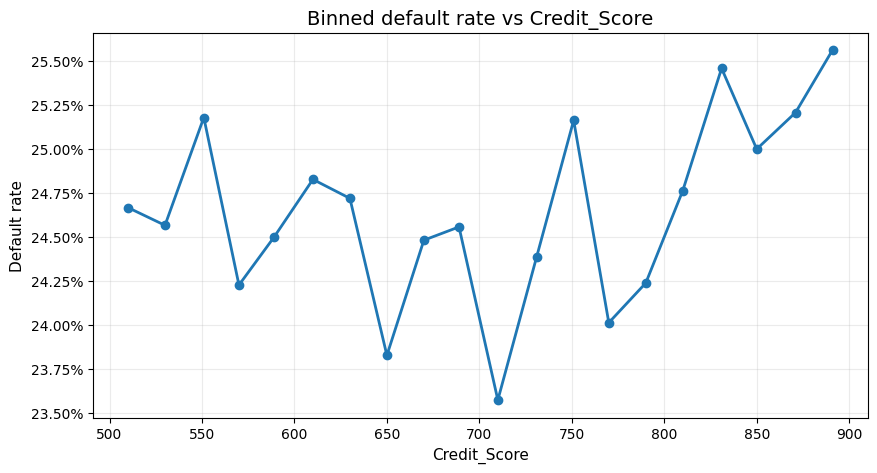

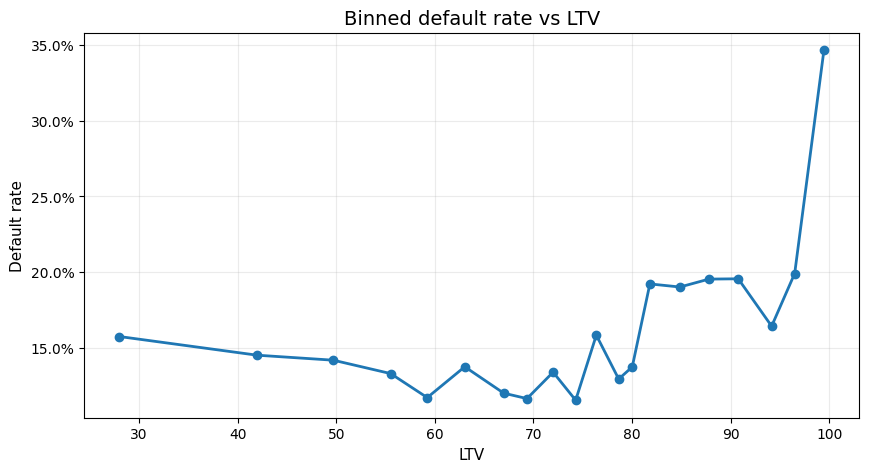

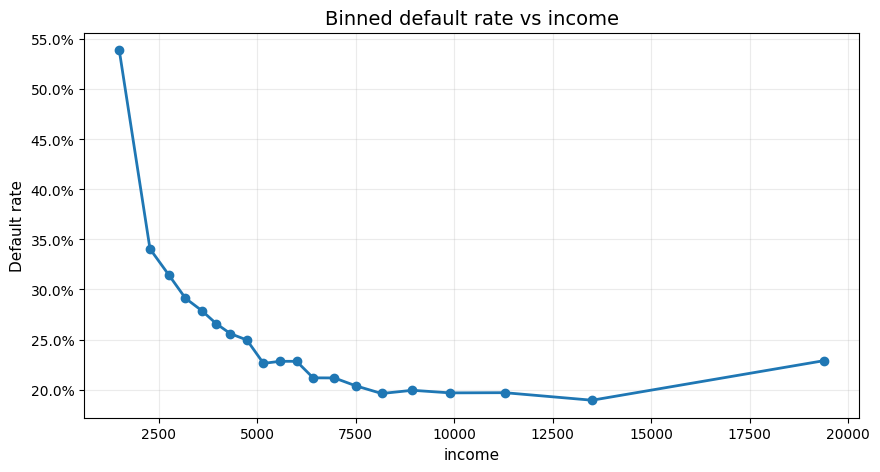

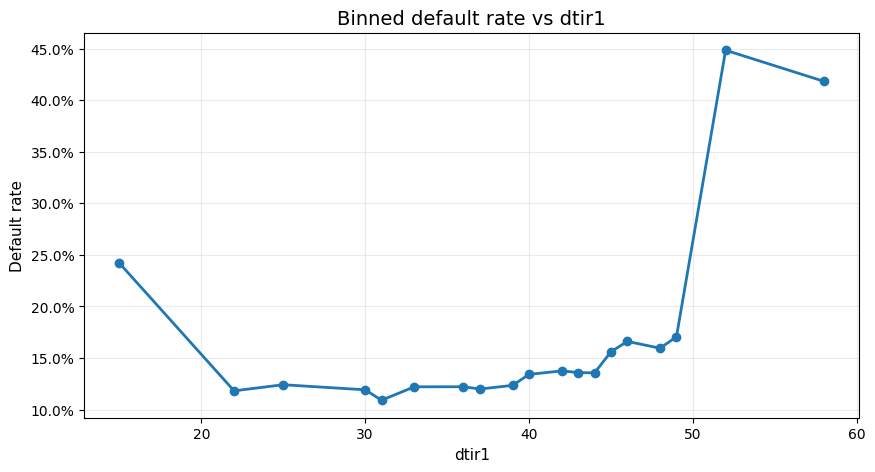

In [8]:
if "Status" not in df.columns:
    raise KeyError("Need Status in df.")

y = df["Status"].astype(float)

for c in num_cols:
    x = pd.to_numeric(df[c], errors="coerce")
    tmp = pd.DataFrame({"x": x, "y": y}).dropna()
    if tmp.shape[0] < 500:
        print(f"Skipping {c}: too few non-missing rows ({tmp.shape[0]})")
        continue

    # bin into quantiles for stable rate estimate
    try:
        tmp["bin"] = pd.qcut(tmp["x"], q=20, duplicates="drop")
    except ValueError:
        print(f"Skipping {c}: not enough unique values for binning")
        continue

    g = tmp.groupby("bin", observed=True).agg(
        x_mid=("x", "median"),
        default_rate=("y", "mean"),
        n=("y", "size")
    ).reset_index(drop=True).sort_values("x_mid")

    fig, ax = plt.subplots()
    ax.plot(g["x_mid"], g["default_rate"], marker="o", linewidth=2)
    ax.set_title(f"Binned default rate vs {c}")
    ax.set_xlabel(c)
    ax.set_ylabel("Default rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    plt.show()

The binned default rate plots illustrate how borrower and loan characteristics relate to default probability across the dataset. Default rates tend to decline as loan amount increases, suggesting that borrowers taking larger loans may have stronger financial profiles or underwriting standards. In contrast, default risk generally increases with higher interest rates, consistent with the interpretation that interest rates partially reflect underlying borrower risk. The relationship between credit score and default appears relatively stable, with only modest variation across score ranges, though slightly higher default rates are observed at the extreme ends. For loan-to-value (LTV), default rates remain relatively moderate across most of the distribution but increase sharply at very high LTV levels, indicating elevated risk for borrowers with minimal equity in the property. Income shows a clear inverse relationship with default, where lower-income borrowers experience substantially higher default rates, while default probability stabilizes at lower levels for higher-income groups. Similarly, debt-to-income ratio (DTI) demonstrates a strong nonlinear relationship with default risk, with default rates rising sharply once DTI exceeds roughly 50%, indicating increased repayment strain. These patterns suggest that several predictors exhibit nonlinear relationships with default probability, supporting the use of a Bayesian logistic regression as a baseline model and a Bayesian Generalized Additive Model (GAM) to flexibly capture nonlinear effects while maintaining probabilistic interpretability.

Categorical effects (default rate by category, top K)

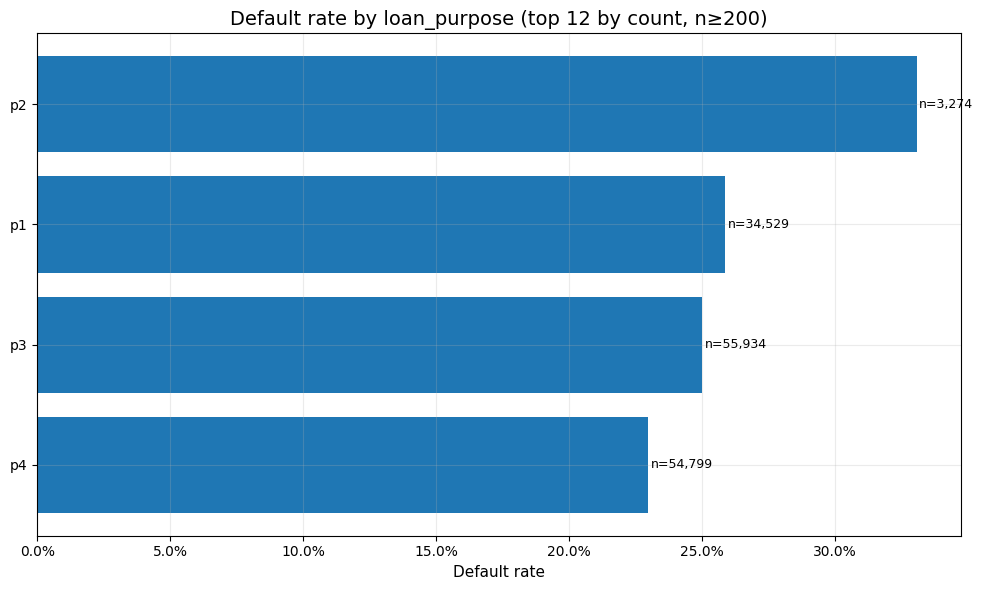

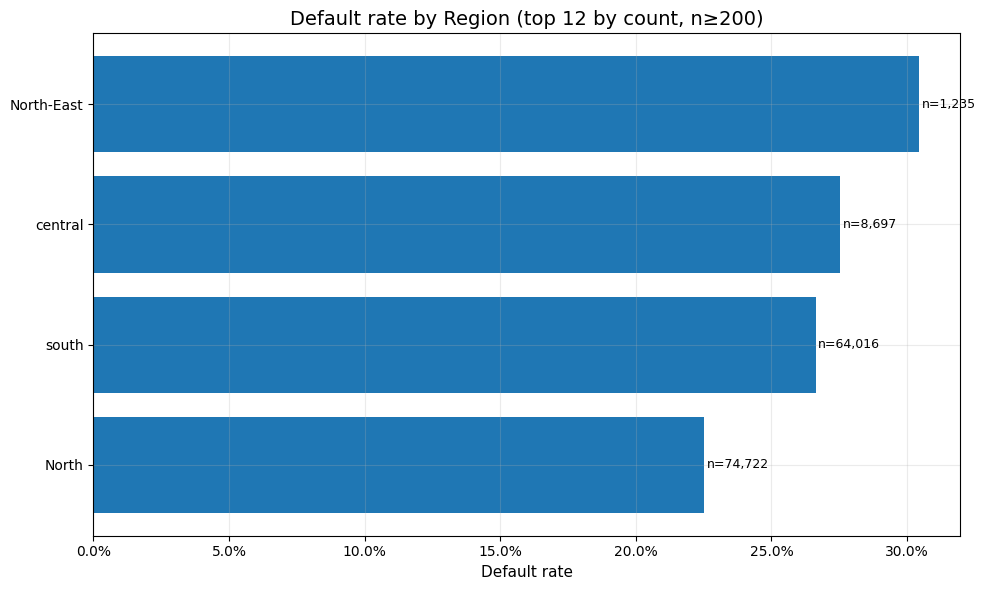

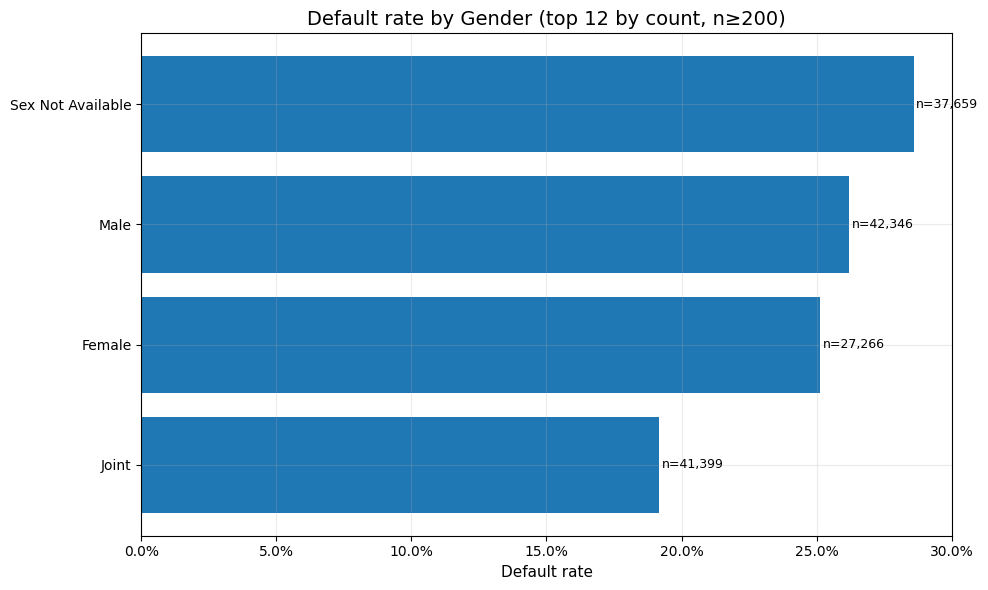

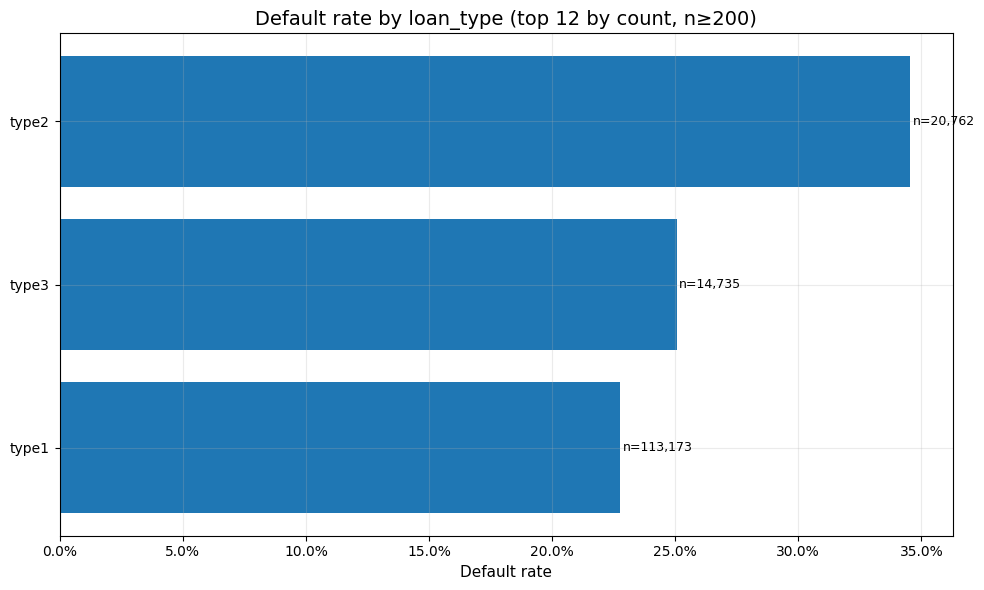

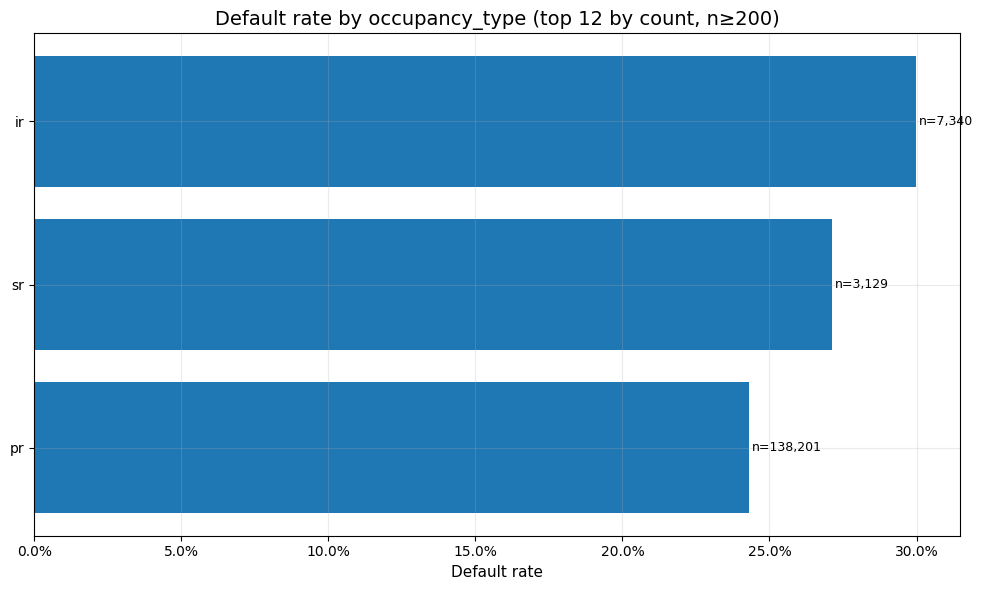

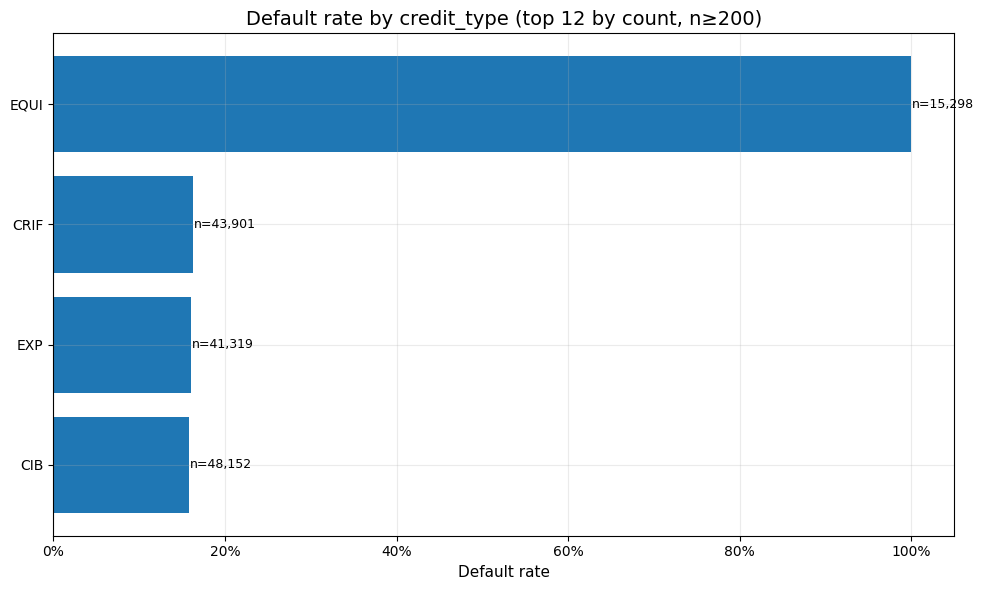

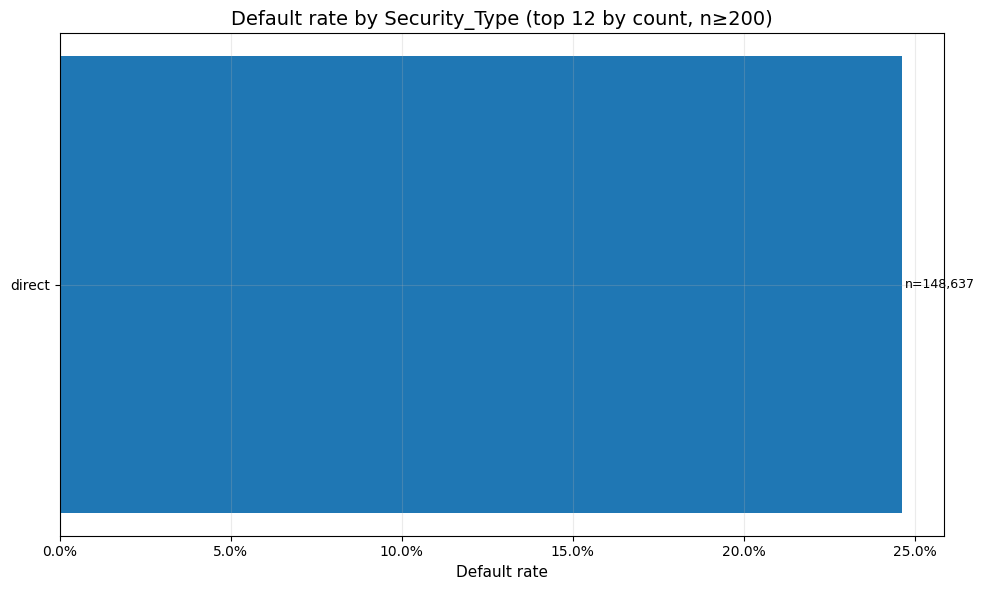

In [9]:
cat_candidates = ["loan_purpose", "Region", "Gender", "loan_type", "occupancy_type", "credit_type", "Security_Type"]
cat_cols = [c for c in cat_candidates if c in df.columns]

def plot_cat_default_rate(col, top_k=12, min_n=200):
    tmp = df[[col, "Status"]].copy()
    tmp[col] = tmp[col].astype("string").str.strip()
    tmp.loc[tmp[col].isin(["", "nan", "None"]), col] = pd.NA

    g = tmp.dropna().groupby(col).agg(
        default_rate=("Status", "mean"),
        n=("Status", "size")
    ).reset_index()

    g = g[g["n"] >= min_n].sort_values("n", ascending=False).head(top_k)
    if g.empty:
        print(f"{col}: no categories meet min_n={min_n}")
        return

    g = g.sort_values("default_rate", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(g[col].astype(str), g["default_rate"])
    ax.set_title(f"Default rate by {col} (top {top_k} by count, n≥{min_n})")
    ax.set_xlabel("Default rate")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

    # annotate counts
    for i, (rate, n) in enumerate(zip(g["default_rate"], g["n"])):
        ax.text(rate + 0.001, i, f"n={int(n):,}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

for c in cat_cols:
    plot_cat_default_rate(c, top_k=12, min_n=200)

The categorical default rate comparisons highlight variation in default risk across borrower and loan characteristics. Default rates differ across loan purposes, with category p2 showing the highest observed default rate, while p4 appears comparatively lower. Regional differences are also present, with the North-East and central regions exhibiting higher default rates relative to the North. Gender categories show relatively similar default rates overall, though the joint category displays somewhat lower default incidence. Differences are more pronounced across loan types, where type2 loans show the highest default rate and type1 loans the lowest among the major categories. Borrower occupancy type also shows variation, with ir displaying higher default rates compared to pr. Credit reporting source (credit_type) reveals notable differences, with the EQUI category exhibiting substantially higher default rates, while CRIF, EXP, and CIB appear considerably lower and similar to each other. Finally, security type shows little variation, as nearly all observations fall under the direct category with a relatively stable default rate. Overall, these categorical patterns suggest that borrower characteristics, loan structure, and regional context may contribute meaningfully to default risk and should be incorporated as explanatory variables in the modeling framework.

Correlation heatmap (numeric only)

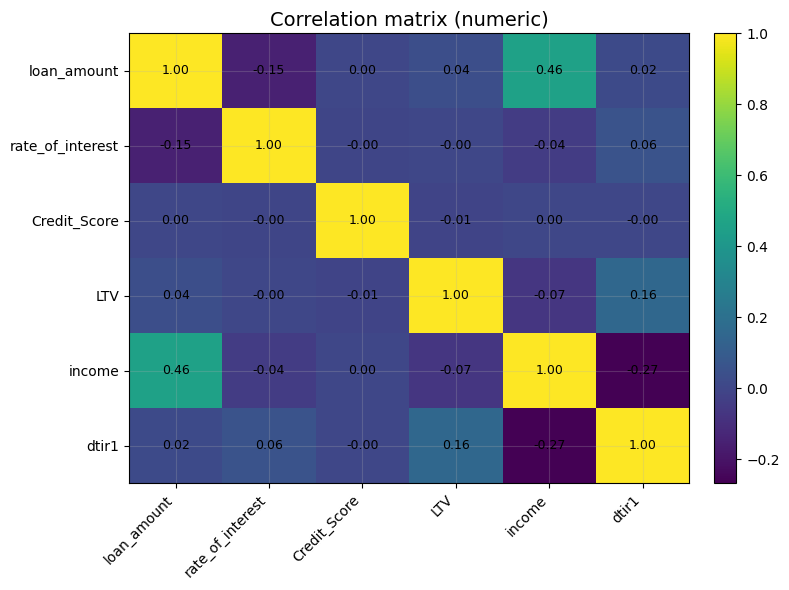

In [10]:
num_for_corr = num_eda.copy()
corr = num_for_corr.corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# add values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9)

ax.set_title("Correlation matrix (numeric)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

The correlation matrix for the primary numeric variables indicates that most predictors exhibit low pairwise correlations, suggesting limited multicollinearity within the dataset. The strongest observed relationship is a moderate positive correlation between loan amount and income (≈0.46), which is expected since borrowers with higher incomes tend to qualify for larger loans. Other relationships, such as between LTV and debt-to-income ratio (≈0.16), are relatively weak. Credit score appears largely independent of the other financial variables in the dataset, while interest rate also shows minimal linear association with most predictors. Overall, the low correlation structure suggests that the numeric variables provide distinct information about borrower risk, making them suitable for inclusion in the modeling framework. The Bayesian logistic regression and Bayesian GAM models further mitigate potential multicollinearity through regularization and flexible functional forms, ensuring stable estimation while capturing meaningful relationships between predictors and default risk.

##Model-ready prep (Bayesian Logit + Bayesian GAM)

Cleaning + define columns (no leakage yet)

In [11]:
# Copy to avoid mutating the raw df
df0 = df.copy()

# Standardize string columns: strip, treat blanks as missing
obj_cols = df0.select_dtypes(include=["object"]).columns
for c in obj_cols:
    df0[c] = df0[c].astype("string").str.strip()
    df0.loc[df0[c].isin(["", "nan", "None"]), c] = pd.NA

# Ensure target is int 0/1
df0["Status"] = pd.to_numeric(df0["Status"], errors="coerce").astype("Int64")

# Choose columns (edit if you want)
NUM_COLS = [c for c in ["loan_amount","rate_of_interest","Credit_Score","LTV","income","dtir1","Interest_rate_spread","Upfront_charges","property_value","term"] if c in df0.columns]
CAT_COLS = [c for c in ["loan_purpose","Region","Gender","loan_type","occupancy_type","credit_type","Security_Type","approv_in_adv","loan_limit","business_or_commercial"] if c in df0.columns]

# Coerce numeric columns
for c in NUM_COLS:
    df0[c] = pd.to_numeric(df0[c], errors="coerce")

# Drop rows with missing target
df0 = df0.dropna(subset=["Status"]).copy()

print("Using numeric:", NUM_COLS)
print("Using categorical:", CAT_COLS)
print("Post-clean shape:", df0.shape)

Using numeric: ['loan_amount', 'rate_of_interest', 'Credit_Score', 'LTV', 'income', 'dtir1', 'Interest_rate_spread', 'Upfront_charges', 'property_value', 'term']
Using categorical: ['loan_purpose', 'Region', 'Gender', 'loan_type', 'occupancy_type', 'credit_type', 'Security_Type', 'approv_in_adv', 'loan_limit', 'business_or_commercial']
Post-clean shape: (148670, 34)


Train/valid/test split (keeps class balance)

In [12]:
from sklearn.model_selection import train_test_split

X_all = df0[NUM_COLS + CAT_COLS].copy()
y_all = df0["Status"].astype(int).values

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=42, stratify=y_all
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)
print("Default rates:",
      f"train={y_train.mean():.3f}, valid={y_valid.mean():.3f}, test={y_test.mean():.3f}")

Train: (104069, 20) Valid: (22300, 20) Test: (22301, 20)
Default rates: train=0.246, valid=0.246, test=0.246


Design matrix for Bayesian Logistic Regression (one-hot cats + scaled nums)

In [13]:

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# --- split numeric / categorical cleanly (avoid pandas <NA> issues) ---
X_train_num = X_train[NUM_COLS].apply(pd.to_numeric, errors="coerce").astype(float)
X_valid_num = X_valid[NUM_COLS].apply(pd.to_numeric, errors="coerce").astype(float)
X_test_num  = X_test[NUM_COLS].apply(pd.to_numeric, errors="coerce").astype(float)

# categorical: force pure python strings; fill missing with sentinel
X_train_cat = X_train[CAT_COLS].astype("object").where(lambda x: x.notna(), "__MISSING__")
X_valid_cat = X_valid[CAT_COLS].astype("object").where(lambda x: x.notna(), "__MISSING__")
X_test_cat  = X_test[CAT_COLS].astype("object").where(lambda x: x.notna(), "__MISSING__")

# combine back (safe: no pd.NA remains)
X_train_skl = pd.concat([X_train_num, X_train_cat], axis=1)
X_valid_skl = pd.concat([X_valid_num, X_valid_cat], axis=1)
X_test_skl  = pd.concat([X_test_num,  X_test_cat],  axis=1)

# --- sklearn preprocessing ---
num_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe = Pipeline(steps=[
    # already has "__MISSING__", but keep imputer as a safety net
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_logit = ColumnTransformer(
    transformers=[
        ("num", num_pipe, NUM_COLS),
        ("cat", cat_pipe, CAT_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_logit_train = preprocess_logit.fit_transform(X_train_skl)
X_logit_valid = preprocess_logit.transform(X_valid_skl)
X_logit_test  = preprocess_logit.transform(X_test_skl)

feature_names_logit = preprocess_logit.get_feature_names_out()

print("X_logit_train:", X_logit_train.shape)
print("X_logit_valid:", X_logit_valid.shape)
print("X_logit_test :", X_logit_test.shape)
print("Example features:", feature_names_logit[:20])

X_logit_train: (104069, 43)
X_logit_valid: (22300, 43)
X_logit_test : (22301, 43)
Example features: ['loan_amount' 'rate_of_interest' 'Credit_Score' 'LTV' 'income' 'dtir1'
 'Interest_rate_spread' 'Upfront_charges' 'property_value' 'term'
 'loan_purpose___MISSING__' 'loan_purpose_p1' 'loan_purpose_p2'
 'loan_purpose_p3' 'loan_purpose_p4' 'Region_North' 'Region_North-East'
 'Region_central' 'Region_south' 'Gender_Female']


Bayesian GAM design matrices

In [14]:
# ============================================================
#Design matrix for Bayesian GAM
# Robust fix: numeric -> float + np.nan; categorical -> "__MISSING__"
# ============================================================

from sklearn.preprocessing import SplineTransformer

N_KNOTS = 8
DEGREE = 3

num_gam_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("spline", SplineTransformer(n_knots=N_KNOTS, degree=DEGREE, include_bias=False)),
    ("scale", StandardScaler()),  # helpful for MCMC stability
])

cat_gam_pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_gam = ColumnTransformer(
    transformers=[
        ("num_spline", num_gam_pipe, NUM_COLS),
        ("cat", cat_gam_pipe, CAT_COLS),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_gam_train = preprocess_gam.fit_transform(X_train_skl)
X_gam_valid = preprocess_gam.transform(X_valid_skl)
X_gam_test  = preprocess_gam.transform(X_test_skl)

feature_names_gam = preprocess_gam.get_feature_names_out()

print("X_gam_train:", X_gam_train.shape)
print("X_gam_valid:", X_gam_valid.shape)
print("X_gam_test :", X_gam_test.shape)
print("Example GAM features:", feature_names_gam[:25])

X_gam_train: (104069, 123)
X_gam_valid: (22300, 123)
X_gam_test : (22301, 123)
Example GAM features: ['loan_amount_sp_0' 'loan_amount_sp_1' 'loan_amount_sp_2'
 'loan_amount_sp_3' 'loan_amount_sp_4' 'loan_amount_sp_5'
 'loan_amount_sp_6' 'loan_amount_sp_7' 'loan_amount_sp_8'
 'rate_of_interest_sp_0' 'rate_of_interest_sp_1' 'rate_of_interest_sp_2'
 'rate_of_interest_sp_3' 'rate_of_interest_sp_4' 'rate_of_interest_sp_5'
 'rate_of_interest_sp_6' 'rate_of_interest_sp_7' 'rate_of_interest_sp_8'
 'Credit_Score_sp_0' 'Credit_Score_sp_1' 'Credit_Score_sp_2'
 'Credit_Score_sp_3' 'Credit_Score_sp_4' 'Credit_Score_sp_5'
 'Credit_Score_sp_6']


Design matrix for hierarchical bayesian logistic regression

In [17]:

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd

GROUP_COL = "Region"

if GROUP_COL not in CAT_COLS:
    raise ValueError(f"{GROUP_COL} must be present in CAT_COLS for the hierarchical model.")

# fixed effects exclude the grouping column
NUM_COLS_HIER = NUM_COLS.copy()
CAT_COLS_HIER = [c for c in CAT_COLS if c != GROUP_COL]

print("Hierarchical numeric features:", NUM_COLS_HIER)
print("Hierarchical categorical features:", CAT_COLS_HIER)
print("Grouping column:", GROUP_COL)

# numeric part
X_train_num_h = X_train[NUM_COLS_HIER].apply(pd.to_numeric, errors="coerce").astype(float)
X_valid_num_h = X_valid[NUM_COLS_HIER].apply(pd.to_numeric, errors="coerce").astype(float)
X_test_num_h  = X_test[NUM_COLS_HIER].apply(pd.to_numeric, errors="coerce").astype(float)

# categorical fixed effects
X_train_cat_h = X_train[CAT_COLS_HIER].astype("object").where(lambda x: x.notna(), "__MISSING__")
X_valid_cat_h = X_valid[CAT_COLS_HIER].astype("object").where(lambda x: x.notna(), "__MISSING__")
X_test_cat_h  = X_test[CAT_COLS_HIER].astype("object").where(lambda x: x.notna(), "__MISSING__")

# combine fixed-effect inputs
X_train_h_skl = pd.concat([X_train_num_h, X_train_cat_h], axis=1)
X_valid_h_skl = pd.concat([X_valid_num_h, X_valid_cat_h], axis=1)
X_test_h_skl  = pd.concat([X_test_num_h,  X_test_cat_h],  axis=1)

# preprocess fixed effects
num_pipe_h = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

cat_pipe_h = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_hier = ColumnTransformer(
    transformers=[
        ("num", num_pipe_h, NUM_COLS_HIER),
        ("cat", cat_pipe_h, CAT_COLS_HIER),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

X_hier_train = preprocess_hier.fit_transform(X_train_h_skl)
X_hier_valid = preprocess_hier.transform(X_valid_h_skl)
X_hier_test  = preprocess_hier.transform(X_test_h_skl)

feature_names_hier = preprocess_hier.get_feature_names_out()

print("X_hier_train:", X_hier_train.shape)
print("X_hier_valid:", X_hier_valid.shape)
print("X_hier_test :", X_hier_test.shape)
print("Example hierarchical features:", feature_names_hier[:20])

# build region indices for varying intercept
region_train_raw = X_train[GROUP_COL].astype("object").where(X_train[GROUP_COL].notna(), "__MISSING__")
region_valid_raw = X_valid[GROUP_COL].astype("object").where(X_valid[GROUP_COL].notna(), "__MISSING__")
region_test_raw  = X_test[GROUP_COL].astype("object").where(X_test[GROUP_COL].notna(), "__MISSING__")

# use all region levels from cleaned full data so mapping is stable
all_regions_raw = df0[GROUP_COL].astype("object").where(df0[GROUP_COL].notna(), "__MISSING__")
region_categories = np.sort(all_regions_raw.astype(str).unique())

region_to_idx = {r: i for i, r in enumerate(region_categories)}

region_idx_train = region_train_raw.astype(str).map(region_to_idx).values
region_idx_valid = region_valid_raw.astype(str).map(region_to_idx).values
region_idx_test  = region_test_raw.astype(str).map(region_to_idx).values

n_regions = len(region_categories)

print("Number of regions:", n_regions)
print("Region categories:", region_categories)
print("region_idx_train shape:", region_idx_train.shape)
print("region_idx_valid shape:", region_idx_valid.shape)
print("region_idx_test shape :", region_idx_test.shape)



Hierarchical numeric features: ['loan_amount', 'rate_of_interest', 'Credit_Score', 'LTV', 'income', 'dtir1', 'Interest_rate_spread', 'Upfront_charges', 'property_value', 'term']
Hierarchical categorical features: ['loan_purpose', 'Gender', 'loan_type', 'occupancy_type', 'credit_type', 'Security_Type', 'approv_in_adv', 'loan_limit', 'business_or_commercial']
Grouping column: Region
X_hier_train: (104069, 39)
X_hier_valid: (22300, 39)
X_hier_test : (22301, 39)
Example hierarchical features: ['loan_amount' 'rate_of_interest' 'Credit_Score' 'LTV' 'income' 'dtir1'
 'Interest_rate_spread' 'Upfront_charges' 'property_value' 'term'
 'loan_purpose___MISSING__' 'loan_purpose_p1' 'loan_purpose_p2'
 'loan_purpose_p3' 'loan_purpose_p4' 'Gender_Female' 'Gender_Joint'
 'Gender_Male' 'Gender_Sex Not Available' 'loan_type_type1']
Number of regions: 4
Region categories: ['North' 'North-East' 'central' 'south']
region_idx_train shape: (104069,)
region_idx_valid shape: (22300,)
region_idx_test shape : (22

##MODELING




Bayesian Logistic Regression (baseline)

In [15]:
import pymc as pm
import numpy as np

X = X_logit_train
y = y_train

with pm.Model() as bayes_logit:

    beta = pm.Normal("beta", mu=0, sigma=1, shape=X.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    logit_p = intercept + pm.math.dot(X, beta)

    p = pm.math.sigmoid(logit_p)

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace_logit = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9
    )

Output()

ERROR:pymc.stats.convergence:There were 3845 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Bayesian GAM (main model)

In [16]:
X = X_gam_train
y = y_train

with pm.Model() as bayes_gam:

    beta = pm.Normal("beta", mu=0, sigma=1, shape=X.shape[1])
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    logit_p = intercept + pm.math.dot(X, beta)

    p = pm.math.sigmoid(logit_p)

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace_gam = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9
    )

Output()

ERROR:pymc.stats.convergence:There were 4000 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Hierarchical bayesian logistic regression


In [18]:
import pymc as pm
import numpy as np

X = X_hier_train
y = y_train
region_idx = region_idx_train

coords = {
    "feature": feature_names_hier,
    "region": region_categories
}

with pm.Model(coords=coords) as bayes_hier_logit:

    beta = pm.Normal("beta", mu=0, sigma=1, dims="feature")
    intercept = pm.Normal("intercept", mu=0, sigma=2)

    sigma_region = pm.HalfNormal("sigma_region", sigma=1.0)
    region_offset = pm.Normal("region_offset", mu=0, sigma=1, dims="region")

    alpha_region = pm.Deterministic(
        "alpha_region",
        intercept + sigma_region * region_offset,
        dims="region"
    )

    logit_p = alpha_region[region_idx] + pm.math.dot(X, beta)

    p = pm.math.sigmoid(logit_p)

    y_obs = pm.Bernoulli("y_obs", p=p, observed=y)

    trace_hier_logit = pm.sample(
        1000,
        tune=1000,
        target_accept=0.9
    )

Output()

ERROR:pymc.stats.convergence:There were 3982 divergences after tuning. Increase `target_accept` or reparameterize.
ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


#EVALUATION METRICS

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    accuracy_score
)

# prediction helpers

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def posterior_mean_pred(trace, X):
    beta_mean = trace.posterior["beta"].mean(dim=("chain","draw")).values
    intercept_mean = trace.posterior["intercept"].mean(dim=("chain","draw")).values
    return sigmoid(intercept_mean + X @ beta_mean)

def posterior_mean_pred_hier(trace, X, region_idx):
    beta_mean = trace.posterior["beta"].mean(dim=("chain","draw")).values
    alpha_region_mean = trace.posterior["alpha_region"].mean(dim=("chain","draw")).values
    return sigmoid(alpha_region_mean[region_idx] + X @ beta_mean)

# compute metrics

def compute_metrics(y_true, p_pred):

    y_hat = (p_pred >= 0.5).astype(int)

    return {
        "AUROC": roc_auc_score(y_true, p_pred),
        "PR_AUC": average_precision_score(y_true, p_pred),
        "LogLoss": log_loss(y_true, p_pred),
        "Brier": brier_score_loss(y_true, p_pred),
        "Accuracy": accuracy_score(y_true, y_hat)
    }

# generate predictions

p_logit_train = posterior_mean_pred(trace_logit, X_logit_train)
p_logit_valid = posterior_mean_pred(trace_logit, X_logit_valid)
p_logit_test  = posterior_mean_pred(trace_logit, X_logit_test)

p_gam_train = posterior_mean_pred(trace_gam, X_gam_train)
p_gam_valid = posterior_mean_pred(trace_gam, X_gam_valid)
p_gam_test  = posterior_mean_pred(trace_gam, X_gam_test)

p_hier_train = posterior_mean_pred_hier(trace_hier_logit, X_hier_train, region_idx_train)
p_hier_valid = posterior_mean_pred_hier(trace_hier_logit, X_hier_valid, region_idx_valid)
p_hier_test  = posterior_mean_pred_hier(trace_hier_logit, X_hier_test, region_idx_test)

# build evaluation table

rows = []

for split, y_true, p_logit, p_gam, p_hier in [
    ("train", y_train, p_logit_train, p_gam_train, p_hier_train),
    ("valid", y_valid, p_logit_valid, p_gam_valid, p_hier_valid),
    ("test",  y_test,  p_logit_test,  p_gam_test,  p_hier_test)
]:

    rows.append({"model":"Bayesian_Logit", "split":split, **compute_metrics(y_true, p_logit)})
    rows.append({"model":"Bayesian_GAM", "split":split, **compute_metrics(y_true, p_gam)})
    rows.append({"model":"Hierarchical_Logit", "split":split, **compute_metrics(y_true, p_hier)})

results = pd.DataFrame(rows)

display(results.round(4))

# cleaner comparison table

summary = results.pivot(index="model", columns="split")
display(summary.round(4))

/tmp/ipykernel_3155/3806557965.py:16: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))
/tmp/ipykernel_3155/3806557965.py:16: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


,model,split,AUROC,PR_AUC,LogLoss,Brier,Accuracy
0,Bayesian_Logit,train,0.7963,0.7130,0.3808,0.1159,0.8561
1,Bayesian_GAM,train,0.5340,0.2456,1.1005,0.3447,0.4969
2,Hierarchical_Logit,train,0.7789,0.6943,0.5164,0.1691,0.7590
3,Bayesian_Logit,valid,0.7927,0.7115,0.3815,0.1164,0.8559
4,Bayesian_GAM,valid,0.5355,0.2459,1.1010,0.3438,0.4978
5,Hierarchical_Logit,valid,0.7764,0.6936,0.5170,0.1695,0.7573
6,Bayesian_Logit,test,0.7951,0.7164,0.3777,0.1148,0.8584
7,Bayesian_GAM,test,0.5290,0.2436,1.1137,0.3471,0.4914
8,Hierarchical_Logit,test,0.7816,0.6990,0.5150,0.1690,0.7610


AUROC                  PR_AUC                 LogLoss  \
split                 test   train   valid    test   train   valid    test   
model                                                                        
Bayesian_GAM        0.5290  0.5340  0.5355  0.2436  0.2456  0.2459  1.1137   
Bayesian_Logit      0.7951  0.7963  0.7927  0.7164  0.7130  0.7115  0.3777   
Hierarchical_Logit  0.7816  0.7789  0.7764  0.6990  0.6943  0.6936  0.5150   

                                     Brier                 Accuracy          \
split                train   valid    test   train   valid     test   train   
model                                                                         
Bayesian_GAM        1.1005  1.1010  0.3471  0.3447  0.3438   0.4914  0.4969   
Bayesian_Logit      0.3808  0.3815  0.1148  0.1159  0.1164   0.8584  0.8561   
Hierarchical_Logit  0.5164  0.5170  0.1690  0.1691  0.1695   0.7610  0.7590   

                            
split                valid  
model                       
Bayesian_GAM        0.4978  
Bayesian_Logit      0.8559  
Hierarchical_Logit  0.7573

Model performance was evaluated across the training, validation, and test datasets using several complementary metrics: AUROC, PR-AUC, LogLoss, Brier score, and classification accuracy. These metrics collectively measure both discriminative ability (how well the model separates default vs. non-default loans) and probabilistic calibration (how accurate the predicted probabilities are).

Across all evaluation splits, the Bayesian Logistic Regression model consistently achieved the strongest performance, with a validation AUROC of approximately 0.79, PR-AUC of 0.71, Brier score of 0.116, and classification accuracy of about 85.6%. The Brier score and LogLoss are particularly important in credit risk modeling because lenders rely on well-calibrated probabilities to estimate expected losses and make underwriting decisions. The logistic regression model achieved the lowest values for both metrics, indicating that its predicted default probabilities are both stable and well-calibrated. This model performs well because the relationship between borrower characteristics (credit score, loan-to-value ratio, income, debt-to-income ratio, and interest rate) and default risk is largely monotonic and approximately linear on the log-odds scale, which aligns well with the assumptions of logistic regression. In consumer lending and mortgage underwriting, these financial variables often affect risk in predictable directions, making logistic regression a strong and interpretable baseline.

The Hierarchical Bayesian Logistic Regression model ranked second in performance. This model extends the logistic framework by introducing region-level varying intercepts, allowing baseline default risk to differ across geographic regions. In theory, this structure can capture regional economic conditions, housing markets, or policy differences that influence loan performance. However, in this dataset the hierarchical structure did not substantially improve predictive accuracy. The hierarchical model produced slightly lower AUROC values (≈0.78) and higher Brier and LogLoss values compared with the standard logistic model. This suggests that while some regional variation may exist, the majority of predictive signal is already captured by borrower-level financial variables such as credit score, leverage (LTV), and repayment burden (DTI). As a result, the additional hierarchical complexity did not translate into better predictive performance.

The Bayesian Generalized Additive Model (GAM) performed substantially worse than the other models, with AUROC values close to 0.53, which is only slightly better than random classification. The GAM was designed to capture nonlinear relationships between predictors and default risk by expanding numeric variables into spline basis functions. While this approach can be powerful when strong nonlinearities exist, it also greatly increases the number of model parameters. In this case, the spline expansion likely introduced excessive model flexibility relative to the available signal in the data. Combined with weakly informative priors and the complexity of MCMC estimation, this resulted in unstable parameter estimates and poorly calibrated predictions. Consequently, the model struggled to identify meaningful relationships between borrower characteristics and default outcomes.

Overall, the models ranked as follows in terms of predictive performance:

- Bayesian Logistic Regression (Best) – highest AUROC and PR-AUC, lowest Brier and LogLoss, and most stable predictions.

- Hierarchical Bayesian Logistic Regression – slightly lower discrimination and calibration; regional random effects did not materially improve predictive power.

- Bayesian GAM (Worst) – excessive flexibility from spline expansions led to unstable estimates and near-random classification performance.

Given these results, the Bayesian Logistic Regression model was selected as the final model for predicting loan default probability. It provides the best balance of predictive accuracy, calibration, and interpretability, which is particularly important in financial risk modeling where transparent and reliable probability estimates are required for underwriting and portfolio risk assessment.

#ANALYST EXPLANATION ENGINE

In [21]:
# analyst explanation engine for final bayesian logistic regression model

import numpy as np
import pandas as pd

# helper functions

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def risk_label(prob):
    if prob < 0.10:
        return "low"
    elif prob < 0.25:
        return "moderate"
    elif prob < 0.40:
        return "elevated"
    else:
        return "high"

def pretty_var_name(v):
    mapping = {
        "loan_amount": "loan amount",
        "rate_of_interest": "interest rate",
        "Credit_Score": "credit score",
        "LTV": "loan-to-value ratio",
        "income": "income",
        "dtir1": "debt-to-income ratio",
        "Interest_rate_spread": "interest rate spread",
        "Upfront_charges": "upfront charges",
        "property_value": "property value",
        "term": "loan term",
        "loan_type": "loan type",
        "occupancy_type": "occupancy type",
        "credit_type": "credit type",
        "Gender": "gender",
        "loan_purpose": "loan purpose",
        "Region": "region",
        "Security_Type": "security type",
        "approv_in_adv": "approval in advance",
        "loan_limit": "loan limit",
        "business_or_commercial": "business or commercial flag"
    }
    return mapping.get(v, v.replace("_", " "))

def format_value(var, value):
    if pd.isna(value):
        return "missing"
    if var in ["rate_of_interest", "Interest_rate_spread"]:
        return f"{value:.2f}%"
    elif var == "Credit_Score":
        return f"{value:.0f}"
    elif var == "LTV":
        return f"{value:.1f}%"
    elif var == "dtir1":
        return f"{value:.1f}"
    elif var in ["income", "loan_amount", "property_value", "Upfront_charges"]:
        return f"${value:,.0f}"
    elif var == "term":
        return f"{value:.0f} months"
    else:
        return str(value)

# map encoded feature names back to raw variables
# this works with names like:
#   loan_amount
#   loan_type_type2
#   Gender_Male
#   loan_purpose_p1

RAW_VARS_LOGIT = NUM_COLS + CAT_COLS

def feature_to_raw_var(feature_name, raw_vars):
    # exact match first
    if feature_name in raw_vars:
        return feature_name

    # longest prefix match next
    candidates = sorted(raw_vars, key=len, reverse=True)
    for var in candidates:
        if feature_name.startswith(var + "_"):
            return var

    return feature_name

# range-based explanations for numeric variables

def explain_numeric_variable(var, raw_value, contribution):
    direction_up = contribution > 0

    if pd.isna(raw_value):
        return (
            f"{pretty_var_name(var).capitalize()} is missing, and the model treats "
            f"missingness as part of the borrower risk profile."
        )

    if var == "Credit_Score":
        if raw_value < 580:
            base = (
                f"The borrower's credit score is {raw_value:.0f}, which falls in a very weak credit range. "
                f"This level is generally associated with weaker historical repayment performance."
            )
        elif raw_value < 670:
            base = (
                f"The borrower's credit score is {raw_value:.0f}, which is below prime quality. "
                f"This typically indicates a somewhat riskier borrower profile."
            )
        elif raw_value < 740:
            base = (
                f"The credit score is {raw_value:.0f}, which is in a near-prime to solid range. "
                f"This usually reflects acceptable repayment history."
            )
        else:
            base = (
                f"The credit score is {raw_value:.0f}, which is strong. "
                f"Borrowers in this range generally demonstrate stronger credit quality."
            )

        tail = (
            " In this prediction, credit score contributes upward pressure on default risk."
            if direction_up else
            " In this prediction, credit score helps reduce default risk."
        )
        return base + tail

    elif var == "LTV":
        if raw_value < 60:
            base = (
                f"The loan-to-value ratio is {raw_value:.1f}%, indicating substantial borrower equity. "
                f"Lower leverage generally reduces default incentives."
            )
        elif raw_value < 80:
            base = (
                f"The loan-to-value ratio is {raw_value:.1f}%, which is moderate. "
                f"This suggests the borrower retains a meaningful equity cushion."
            )
        elif raw_value < 90:
            base = (
                f"The loan-to-value ratio is {raw_value:.1f}%, which indicates relatively high leverage. "
                f"At this level, the borrower has less room to absorb financial stress."
            )
        else:
            base = (
                f"The loan-to-value ratio is {raw_value:.1f}%, which is very high. "
                f"This implies limited equity and greater vulnerability if repayment stress occurs."
            )

        tail = (
            " The model treats this as a risk-increasing feature."
            if direction_up else
            " The model treats this as an offsetting strength for this borrower."
        )
        return base + tail

    elif var == "dtir1":
        if raw_value < 20:
            base = (
                f"The debt-to-income ratio is {raw_value:.1f}, which is very low. "
                f"This implies a relatively light debt burden compared with income."
            )
        elif raw_value < 36:
            base = (
                f"The debt-to-income ratio is {raw_value:.1f}, which is generally manageable. "
                f"This suggests repayment burden is likely sustainable."
            )
        elif raw_value < 43:
            base = (
                f"The debt-to-income ratio is {raw_value:.1f}, which is somewhat elevated. "
                f"At this level, debt obligations place more pressure on cash flow."
            )
        else:
            base = (
                f"The debt-to-income ratio is {raw_value:.1f}, which is high. "
                f"This indicates significant repayment burden relative to income."
            )

        tail = (
            " The model associates this with higher default risk."
            if direction_up else
            " The model associates this with lower default risk."
        )
        return base + tail

    elif var == "rate_of_interest":
        if raw_value < 3.5:
            base = (
                f"The interest rate is {raw_value:.2f}%, which is relatively low. "
                f"Lower rates reduce monthly payment burden and often correspond to stronger borrower quality."
            )
        elif raw_value < 5.0:
            base = (
                f"The interest rate is {raw_value:.2f}%, which is moderate. "
                f"This still contributes to repayment cost but remains within a typical range."
            )
        else:
            base = (
                f"The interest rate is {raw_value:.2f}%, which is high relative to lower-rate loans. "
                f"Higher rates raise monthly payment burden and may reflect risk-based pricing."
            )

        tail = (
            " In this prediction, the rate contributes upward pressure on risk."
            if direction_up else
            " In this prediction, the rate contributes downward pressure on risk."
        )
        return base + tail

    elif var == "income":
        if raw_value < 4000:
            base = (
                f"Reported income is {format_value(var, raw_value)}, which is relatively low. "
                f"Lower income can limit financial flexibility and reduce shock absorption capacity."
            )
        elif raw_value < 8000:
            base = (
                f"Reported income is {format_value(var, raw_value)}, which is moderate. "
                f"This may support repayment, but resilience still depends on leverage and debt burden."
            )
        elif raw_value < 15000:
            base = (
                f"Reported income is {format_value(var, raw_value)}, which is solid. "
                f"Higher income generally improves repayment capacity."
            )
        else:
            base = (
                f"Reported income is {format_value(var, raw_value)}, which is high. "
                f"Borrowers at this level typically have more capacity to sustain payments."
            )

        tail = (
            " In this case, the model still views income as contributing upward pressure on risk."
            if direction_up else
            " In this case, income acts as an offsetting strength that lowers predicted risk."
        )
        return base + tail

    elif var == "loan_amount":
        if raw_value < 150000:
            base = (
                f"The loan amount is {format_value(var, raw_value)}, which is relatively small. "
                f"Smaller balances may reduce absolute payment burden."
            )
        elif raw_value < 400000:
            base = (
                f"The loan amount is {format_value(var, raw_value)}, which is moderate for this portfolio. "
                f"At this level, risk depends more on affordability and leverage than size alone."
            )
        else:
            base = (
                f"The loan amount is {format_value(var, raw_value)}, which is large. "
                f"Larger loans increase exposure size, although they may also reflect stronger underwriting."
            )

        tail = (
            " Here, the model interprets loan size as increasing risk."
            if direction_up else
            " Here, the model interprets loan size as reducing risk relative to the broader profile."
        )
        return base + tail

    elif var == "property_value":
        base = (
            f"The property value is {format_value(var, raw_value)}. "
            f"Property value affects leverage and borrower equity when considered together with loan size."
        )
        tail = (
            " In this prediction, the model treats property value as increasing risk."
            if direction_up else
            " In this prediction, the model treats property value as reducing risk."
        )
        return base + tail

    elif var == "term":
        base = (
            f"The loan term is {format_value(var, raw_value)}. "
            f"Loan maturity affects payment structure and repayment horizon."
        )
        tail = (
            " In this case, the model associates the term with higher default risk."
            if direction_up else
            " In this case, the model associates the term with lower default risk."
        )
        return base + tail

    else:
        return (
            f"{pretty_var_name(var).capitalize()} has value {format_value(var, raw_value)}. "
            + (
                "The model treats this as increasing predicted risk."
                if direction_up else
                "The model treats this as reducing predicted risk."
            )
        )

# explanations for categorical variables

def explain_categorical_variable(var, raw_value, contribution):
    direction_up = contribution > 0

    if pd.isna(raw_value):
        raw_value = "missing"

    if var == "Gender":
        base = (
            f"The borrower is categorized as {raw_value}. "
            f"This variable reflects historical patterns in the training data rather than a direct causal financial mechanism."
        )
    elif var == "loan_type":
        base = (
            f"The loan is categorized as {raw_value}. "
            f"Different loan structures may show different repayment behavior and underwriting characteristics."
        )
    elif var == "occupancy_type":
        base = (
            f"The occupancy type is {raw_value}. "
            f"Owner-occupied, investor, and secondary-property loans can perform differently because borrower incentives vary."
        )
    elif var == "credit_type":
        base = (
            f"The credit reporting category is {raw_value}. "
            f"This may proxy differences in bureau reporting patterns or borrower segments."
        )
    elif var == "loan_purpose":
        base = (
            f"The loan purpose is {raw_value}. "
            f"Different borrowing purposes may correspond to different underlying risk behavior."
        )
    elif var == "Region":
        base = (
            f"The borrower is associated with the {raw_value} region. "
            f"Regional effects may reflect differences in local economic or housing conditions."
        )
    else:
        base = (
            f"{pretty_var_name(var).capitalize()} is {raw_value}. "
            f"This category contributes based on relationships learned from the training data."
        )

    tail = (
        " For this borrower, the category pushes predicted risk upward."
        if direction_up else
        " For this borrower, the category helps lower predicted risk."
    )

    return base + tail

# predict one borrower with final bayesian logit

def predict_logit_row(raw_row):
    row_df = pd.DataFrame([raw_row])

    # ensure all expected raw columns exist
    for c in NUM_COLS + CAT_COLS:
        if c not in row_df.columns:
            row_df[c] = pd.NA

    row_df = row_df[NUM_COLS + CAT_COLS].copy()

    X_row = preprocess_logit.transform(row_df)

    beta_mean = trace_logit.posterior["beta"].mean(dim=("chain", "draw")).values
    intercept_mean = trace_logit.posterior["intercept"].mean(dim=("chain", "draw")).values

    eta = intercept_mean + X_row @ beta_mean
    prob = sigmoid(eta)

    return prob[0], X_row, beta_mean

# compute variable contributions

def compute_variable_contributions_logit(X_row, beta_mean):
    contrib = X_row.flatten() * beta_mean

    df_contrib = pd.DataFrame({
        "feature": feature_names_logit,
        "contribution": contrib
    })

    df_contrib["variable"] = df_contrib["feature"].apply(
        lambda f: feature_to_raw_var(f, RAW_VARS_LOGIT)
    )

    grouped = (
        df_contrib.groupby("variable", as_index=False)["contribution"]
        .sum()
    )

    grouped["abs_contribution"] = grouped["contribution"].abs()
    grouped = grouped.sort_values("abs_contribution", ascending=False)

    return grouped

# build detailed explanations

def build_detailed_explanations_logit(raw_row, contributions, top_n=3):
    raw = raw_row.copy()

    up = contributions[contributions["contribution"] > 0].head(top_n)
    down = contributions[contributions["contribution"] < 0].head(top_n)

    up_text = []
    down_text = []

    for _, r in up.iterrows():
        var = r["variable"]
        contrib = r["contribution"]
        raw_val = raw[var] if var in raw.index else np.nan

        if var in NUM_COLS:
            up_text.append(explain_numeric_variable(var, raw_val, contrib))
        else:
            up_text.append(explain_categorical_variable(var, raw_val, contrib))

    for _, r in down.iterrows():
        var = r["variable"]
        contrib = r["contribution"]
        raw_val = raw[var] if var in raw.index else np.nan

        if var in NUM_COLS:
            down_text.append(explain_numeric_variable(var, raw_val, contrib))
        else:
            down_text.append(explain_categorical_variable(var, raw_val, contrib))

    return up_text, down_text

# create analyst statement

def generate_statement_logit(prob, contributions, raw_row, top_n=3):
    risk = risk_label(prob)

    statement = (
        f"The model predicts an estimated default probability of {prob*100:.1f}% "
        f"for this borrower, which corresponds to a {risk} risk classification. "
    )

    up = contributions[contributions["contribution"] > 0].head(top_n)
    down = contributions[contributions["contribution"] < 0].head(top_n)

    if len(up) > 0:
        up_names = [pretty_var_name(v) for v in up["variable"].tolist()]
        statement += (
            "The strongest factors increasing risk are "
            + ", ".join(up_names)
            + ". "
        )

    if len(down) > 0:
        down_names = [pretty_var_name(v) for v in down["variable"].tolist()]
        statement += (
            "The strongest offsetting factors are "
            + ", ".join(down_names)
            + ". "
        )

    up_text, down_text = build_detailed_explanations_logit(
        raw_row=raw_row,
        contributions=contributions,
        top_n=top_n
    )

    if up_text:
        statement += "Risk-increasing interpretation: " + " ".join(up_text) + " "

    if down_text:
        statement += "Risk-reducing interpretation: " + " ".join(down_text)

    return statement

# full pipeline

def score_and_explain_logit(raw_row, top_n=3):
    prob, X_row, beta_mean = predict_logit_row(raw_row)

    contributions = compute_variable_contributions_logit(X_row, beta_mean)

    statement = generate_statement_logit(
        prob=prob,
        contributions=contributions,
        raw_row=raw_row,
        top_n=top_n
    )

    return {
        "probability": prob,
        "risk_band": risk_label(prob),
        "statement": statement,
        "contributions": contributions
    }

# example usage

example_row = df0.iloc[0].copy()
example = score_and_explain_logit(example_row, top_n=3)

print(example["statement"])
display(example["contributions"].head(10))

The model predicts an estimated default probability of 33.1% for this borrower, which corresponds to a elevated risk classification. The strongest factors increasing risk are gender, region, approval in advance. The strongest offsetting factors are credit type, security type, occupancy type. Risk-increasing interpretation: The borrower is categorized as Sex Not Available. This variable reflects historical patterns in the training data rather than a direct causal financial mechanism. For this borrower, the category pushes predicted risk upward. The borrower is associated with the south region. Regional effects may reflect differences in local economic or housing conditions. For this borrower, the category pushes predicted risk upward. Approval in advance is nopre. This category contributes based on relationships learned from the training data. For this borrower, the category pushes predicted risk upward. Risk-reducing interpretation: The credit reporting category is EXP. This may proxy 

,variable,contribution,abs_contribution
9,credit_type,-1.492006,1.492006
5,Security_Type,-1.428873,1.428873
16,occupancy_type,-0.525477,0.525477
1,Gender,0.479880,0.479880
4,Region,0.255868,0.255868
8,business_or_commercial,-0.236407,0.236407
7,approv_in_adv,0.227840,0.227840
14,loan_purpose,0.174789,0.174789
10,dtir1,0.156692,0.156692
11,income,0.142560,0.142560


For the selected borrower, the model predicts a default probability of 33.1%, placing the borrower in the elevated risk category according to the model’s risk thresholds. This indicates that the borrower has a materially higher likelihood of default compared with the lower-risk portion of the loan portfolio.

The model identifies several borrower and loan characteristics that contribute to this risk assessment. Among the strongest risk-increasing factors, the model highlights gender classification, regional location, and approval status. The borrower is categorized as “Sex Not Available”, which the model interprets as a higher-risk segment based on patterns observed in the training data. It is important to note that variables such as gender do not imply causal financial risk but instead capture statistical patterns present in the historical dataset. The borrower is also located in the South region, which contributes positively to predicted default risk. This effect may reflect regional economic conditions, housing market dynamics, or historical repayment patterns observed in the data. In addition, the loan was not pre-approved (“nopre”), which may indicate a less streamlined underwriting process or a borrower profile requiring additional review, both of which may correlate with slightly higher risk levels.

At the same time, several factors help offset the borrower’s predicted risk. The most significant protective factors are credit reporting type, security type, and occupancy status. The borrower’s credit reporting source (EXP) contributes strongly toward lowering predicted risk, suggesting that borrowers associated with this reporting category historically demonstrated better repayment performance in the training dataset. Similarly, the security type (“direct”) reduces predicted risk, indicating that loans structured with this security type have historically exhibited stronger performance. The occupancy type (“pr”) also contributes negatively to risk, likely reflecting the fact that certain occupancy arrangements—such as primary residences—are often associated with stronger repayment incentives compared with investment properties.